<a href="https://colab.research.google.com/github/liamyoum/W14-gpt-lab/blob/JUN/gpt-lab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 과제 - PyTorch로 mini GPT 구현

이 노트북은 과제 안내서의 구현 순서를 그대로 따릅니다.

1. 환경설정
2. NSMC 데이터 준비
3. BPE 토크나이저
4. GPTDataset / InputEmbedding
5. MultiHeadAttention
6. GPTModel
7. 사전 학습 유틸리티
8. 감성 분류 미세 조정

각 단계의 `src/` TODO를 구현한 뒤, 바로 아래 pytest 셀로 해당 단계만 확인하세요.

## 1. 환경설정

Colab에서는 GitHub 저장소 URL과 GitHub Personal Access Token을 입력해 저장소를 clone하고 `src/`를 import 경로에 추가합니다.
로컬 VS Code에서는 현재 폴더를 프로젝트 루트로 보고 실행합니다.

In [4]:
# Colab: 이 셀을 가장 먼저 실행하세요.
import os
import subprocess
import sys
from pathlib import Path


def normalize_github_url(url: str) -> str:
    """Colab 입력값을 git clone에 사용할 수 있는 https URL로 정리합니다."""
    url = url.strip()
    if not url:
        raise ValueError("GitHub 저장소 URL을 입력해야 합니다.")
    if url.startswith("github.com/"):
        url = "https://" + url
    if not url.startswith("https://"):
        raise ValueError("저장소 URL은 https://github.com/... 또는 github.com/... 형식이어야 합니다.")
    url = url.rstrip("/")
    if not url.endswith(".git"):
        url += ".git"
    return url


if "google.colab" in sys.modules:
    from getpass import getpass

    repo_url = normalize_github_url(
        input("GitHub 저장소 URL (예: github.com/USERNAME/gpt-lab.git): ")
    )
    token = getpass(
        "GitHub Personal Access Token (Private 저장소인 경우 입력, 공개 저장소면 Enter): "
    ).strip()

    clone_url = repo_url.replace("https://", f"https://{token}@") if token else repo_url
    repo_name = Path(repo_url[:-4]).name if repo_url.endswith(".git") else Path(repo_url).name
    repo_dir = Path("/content") / repo_name

    if not repo_dir.exists():
        subprocess.run(["git", "clone", clone_url, str(repo_dir)], check=True)
        subprocess.run(["git", "remote", "set-url", "origin", repo_url], cwd=repo_dir, check=True)
    else:
        print(f"이미 clone된 저장소를 사용합니다: {repo_dir}")

    os.chdir(repo_dir)

    subprocess.run(["git", "fetch", "origin"], check=True)
    subprocess.run(["git", "checkout", "JUN"], check=True)
    subprocess.run(["git", "pull", "origin", "JUN"], check=True)

else:
    repo_dir = Path(".").resolve()

sys.path.insert(0, str(repo_dir / "src"))

print(f"Repo: {repo_dir}")
print("현재 브랜치:")
subprocess.run(["git", "branch", "--show-current"], cwd=repo_dir, check=True)

print("최근 커밋:")
subprocess.run(["git", "log", "--oneline", "-3"], cwd=repo_dir, check=True)

GitHub 저장소 URL (예: github.com/USERNAME/gpt-lab.git): https://github.com/liamyoum/W14-gpt-lab
GitHub Personal Access Token (Private 저장소인 경우 입력, 공개 저장소면 Enter): ··········
Repo: /content/W14-gpt-lab
현재 브랜치:
최근 커밋:


CompletedProcess(args=['git', 'log', '--oneline', '-3'], returncode=0)

In [5]:
# 단계별 테스트 실행 helper
import subprocess
import sys


def run_pytest(target: str):
    cmd = [sys.executable, "-m", "pytest", target, "-v"]
    print("실행 명령:", " ".join(cmd))
    result = subprocess.run(cmd, cwd=str(repo_dir), text=True, capture_output=True)
    print(result.stdout)
    if result.stderr:
        print(result.stderr)
    if result.returncode != 0:
        print("\n아직 통과하지 못한 테스트가 있습니다. 해당 단계의 TODO를 먼저 구현하세요.")
    else:
        print("\n선택한 테스트를 통과했습니다.")
    return result.returncode

## 2. NSMC 데이터 준비

기본 데이터는 NAVER Sentiment Movie Corpus(NSMC)입니다.
`download_data.py`는 원본 TSV를 내려받고, 사전 학습용 텍스트와 감성 분류용 JSONL을 만듭니다.

In [6]:
from pathlib import Path

try:
    import download_data

    paths = download_data.main()
except Exception as e:
    print("데이터 준비 중 문제가 생겼습니다:", e)
    print("이미 data/ 파일이 있다면 다음 셀부터 계속 진행할 수 있습니다.")

LM_TRAIN_PATH = repo_dir / "data" / "nsmc_lm_train.txt"
LM_VAL_PATH = repo_dir / "data" / "nsmc_lm_val.txt"
print("LM train exists:", LM_TRAIN_PATH.exists(), LM_TRAIN_PATH)
print("LM val exists:", LM_VAL_PATH.exists(), LM_VAL_PATH)

다운로드 중: https://raw.githubusercontent.com/e9t/nsmc/master/ratings_train.txt
저장됨: /content/W14-gpt-lab/data/ratings_train.txt
다운로드 중: https://raw.githubusercontent.com/e9t/nsmc/master/ratings_test.txt
저장됨: /content/W14-gpt-lab/data/ratings_test.txt
사전 학습 train 텍스트: /content/W14-gpt-lab/data/nsmc_lm_train.txt (1,379,486자)
사전 학습 val 텍스트: /content/W14-gpt-lab/data/nsmc_lm_val.txt (120,560자)
감성 분류 train: /content/W14-gpt-lab/data/nsmc_sentiment_train.jsonl (137,996개)
감성 분류 val: /content/W14-gpt-lab/data/nsmc_sentiment_val.jsonl (11,999개)
감성 분류 test: /content/W14-gpt-lab/data/nsmc_sentiment_test.jsonl (49,997개)
LM train exists: True /content/W14-gpt-lab/data/nsmc_lm_train.txt
LM val exists: True /content/W14-gpt-lab/data/nsmc_lm_val.txt


In [7]:
corpus = LM_TRAIN_PATH.read_text(encoding="utf-8") if LM_TRAIN_PATH.exists() else ""
val_corpus = LM_VAL_PATH.read_text(encoding="utf-8") if LM_VAL_PATH.exists() else ""
print("train chars:", len(corpus))
print("val chars:", len(val_corpus))
print(corpus[:200])

train chars: 1379486
val chars: 120560
개재미없다. 감독의 연출력의 한계
이제서야 보게된 대 명작 연출미가 정말 훌륭하다!!!!!!!!
소주미라클을 만들어라
귀여운 캐릭터들도 많이 나와서 보러 가야 겠어요..
블랙 코미디가 싫어요.
평점깎고싶다10글자
TV시리즈가 너무재밌어서 영화는 기대안하고 봤는데 역시....최고네요
개인적 공감이 글쎄?
시작은 니시지마 때문에 봤는데 나름 괜찮은 영화 봤다고


## 3. Step 1 - BPE 토크나이저

구현 파일: `src/bpe.py`

먼저 `pytest tests/test_bpe.py -v`를 통과시키세요. 한국어를 안전하게 다루기 위해 UTF-8 byte-level BPE로 구현해야 합니다.

In [8]:
run_pytest("tests/test_bpe.py")

실행 명령: /usr/bin/python3 -m pytest tests/test_bpe.py -v
============================= test session starts ==============================
platform linux -- Python 3.12.13, pytest-8.4.2, pluggy-1.6.0 -- /usr/bin/python3
cachedir: .pytest_cache
rootdir: /content/W14-gpt-lab
plugins: anyio-4.13.0, typeguard-4.5.2, langsmith-0.8.5
collecting ... collected 6 items

tests/test_bpe.py::TestSpecialTokens::test_special_ids_fixed PASSED      [ 16%]
tests/test_bpe.py::TestBPETokenizer::test_init_special_tokens PASSED     [ 33%]
tests/test_bpe.py::TestBPETokenizer::test_save_load_restores_vocab PASSED [ 50%]
tests/test_bpe.py::TestBPETokenizer::test_encode_decode_restores_original_text PASSED [ 66%]
tests/test_bpe.py::TestBPETokenizer::test_get_special_ids PASSED         [ 83%]
tests/test_bpe.py::TestBPETrain::test_train_increases_vocab PASSED       [100%]

============================== 6 passed in 0.05s ===============================


선택한 테스트를 통과했습니다.


0

In [9]:
# # BPE 구현 후 작은 말뭉치로 인코딩/디코딩 복원을 확인합니다.
# try:
#     from bpe import BPETokenizer

#     tokenizer = BPETokenizer(vocab_size=3000)
#     tokenizer.train(corpus[:5000])
#     sample = "이 영화는 정말 좋았다! English 123"
#     ids = tokenizer.encode(sample, add_bos_eos=True)
#     print(ids[:20])
#     print(tokenizer.decode(ids))
# except NotImplementedError as e:
#     print("BPE TODO 미구현:", e)

Google Drive에 어휘사전 json이 없다면 새로 생성, 있다면 load 하는 Code Block

In [10]:

from pathlib import Path
import time
import sys
import platform
import importlib
import shutil

from google.colab import drive

drive.mount("/content/drive")

# 이미 import된 예전 bpe.py가 있으면 제거
sys.modules.pop("bpe", None)
importlib.invalidate_caches()

from bpe import BPETokenizer


CORPUS_SIZE = 1_500_000
VOCAB_SIZE = 3000 # 어휘 사전 크기 변경하고 싶다면 여기 변경

repo_vocab_path = Path("data/nsmc_bpe_vocab_3000.json") # 여기도 숫자 변경
drive_vocab_dir = Path("/content/drive/MyDrive/W14-gpt-lab/data")
drive_vocab_dir.mkdir(parents=True, exist_ok=True)

drive_vocab_path = drive_vocab_dir / "nsmc_bpe_vocab_3000.json" # 어휘사전 크기에 따라 load를 다르게 하고 싶다면 여기 변경

text = corpus[:CORPUS_SIZE]
tokenizer = BPETokenizer(vocab_size=VOCAB_SIZE)

if drive_vocab_path.exists():
    start = time.perf_counter()
    tokenizer.load(drive_vocab_path)
    elapsed = time.perf_counter() - start
    mode = "loaded_from_drive"
else:
    start = time.perf_counter()
    tokenizer.train(text)
    elapsed = time.perf_counter() - start

    tokenizer.save(drive_vocab_path)
    tokenizer.save(repo_vocab_path)
    mode = "trained_and_saved"

# repo data에도 복사해두기
if drive_vocab_path.exists():
    repo_vocab_path.parent.mkdir(parents=True, exist_ok=True)
    shutil.copy2(drive_vocab_path, repo_vocab_path)

sample = "이 영화는 정말 좋았다! English 123"
ids = tokenizer.encode(sample, add_bos_eos=True)
decoded = tokenizer.decode(ids)

env = "Colab"
try:
    import torch
    device = "GPU" if torch.cuda.is_available() else "CPU"
except ImportError:
    device = "CPU"

print("mode:", mode)
print("environment:", env, device)
print("python:", platform.python_version())
print("corpus_size chars:", len(text))
print("corpus_size bytes:", len(text.encode("utf-8")))
print("vocab_size:", VOCAB_SIZE)
print("actual_vocab_size:", len(tokenizer.id_to_token))
print("training_or_load_time_sec:", round(elapsed, 2))
print("training_or_load_time_min:", round(elapsed / 60, 2))
print("drive_vocab_path:", drive_vocab_path)
print("repo_vocab_path:", repo_vocab_path)
print("decode_ok:", decoded == sample)
print("sample_ids:", ids[:20])
print("decoded:", decoded)

Mounted at /content/drive
mode: loaded_from_drive
environment: Colab GPU
python: 3.12.13
corpus_size chars: 1379486
corpus_size bytes: 3335336
vocab_size: 3000
actual_vocab_size: 3000
training_or_load_time_sec: 0.28
training_or_load_time_min: 0.0
drive_vocab_path: /content/drive/MyDrive/W14-gpt-lab/data/nsmc_bpe_vocab_3000.json
repo_vocab_path: data/nsmc_bpe_vocab_3000.json
decode_ok: True
sample_ids: [2, 267, 1003, 532, 860, 1996, 36, 73, 114, 107, 112, 109, 119, 108, 505, 54, 55, 3]
decoded: 이 영화는 정말 좋았다! English 123


## 4. Step 2 - GPTDataset / InputEmbedding

구현 파일: `src/dataset.py`, `src/embeddings.py`

BPE가 통과한 뒤 데이터셋과 입력 임베딩을 구현합니다.

In [11]:
run_pytest("tests/test_dataset.py")

실행 명령: /usr/bin/python3 -m pytest tests/test_dataset.py -v
============================= test session starts ==============================
platform linux -- Python 3.12.13, pytest-8.4.2, pluggy-1.6.0 -- /usr/bin/python3
cachedir: .pytest_cache
rootdir: /content/W14-gpt-lab
plugins: anyio-4.13.0, typeguard-4.5.2, langsmith-0.8.5
collecting ... collected 4 items

tests/test_dataset.py::TestGPTDataset::test_dataset_length PASSED        [ 25%]
tests/test_dataset.py::TestGPTDataset::test_dataset_getitem_shape PASSED [ 50%]
tests/test_dataset.py::TestCreateDataloader::test_dataloader_batch_shape PASSED [ 75%]
tests/test_dataset.py::TestInputEmbedding::test_input_embedding_shape PASSED [100%]

============================== 4 passed in 2.66s ===============================


선택한 테스트를 통과했습니다.


0

In [12]:
try:
    from bpe import BPETokenizer
    from dataset import create_dataloader
    from embeddings import InputEmbedding

    tokenizer = BPETokenizer(vocab_size=300)
    tokenizer.train(corpus[:5000])
    token_ids = tokenizer.encode(corpus[:5000])
    loader = create_dataloader(token_ids, context_length=32, batch_size=2, shuffle=False)
    inp, tgt = next(iter(loader))
    emb = InputEmbedding(vocab_size=300, emb_dim=32, context_length=32, drop_rate=0.0)
    out = emb(inp)
    print(inp.shape, tgt.shape, out.shape)
except NotImplementedError as e:
    print("Dataset/Embedding TODO 미구현:", e)

torch.Size([2, 32]) torch.Size([2, 32]) torch.Size([2, 32, 32])


## 5. Step 3 - MultiHeadAttention

구현 파일: `src/attention.py`

Q/K/V shape, head 분리, causal mask를 차례로 확인하세요.

In [13]:
run_pytest("tests/test_attention.py")

실행 명령: /usr/bin/python3 -m pytest tests/test_attention.py -v
============================= test session starts ==============================
platform linux -- Python 3.12.13, pytest-8.4.2, pluggy-1.6.0 -- /usr/bin/python3
cachedir: .pytest_cache
rootdir: /content/W14-gpt-lab
plugins: anyio-4.13.0, typeguard-4.5.2, langsmith-0.8.5
collecting ... collected 2 items

tests/test_attention.py::TestMultiHeadAttention::test_mha_output_shape PASSED [ 50%]
tests/test_attention.py::TestMultiHeadAttention::test_mha_causal_mask_future_zero PASSED [100%]

============================== 2 passed in 1.73s ===============================


선택한 테스트를 통과했습니다.


0

## 6. Step 4 - GPTModel

구현 파일: `src/model.py`

LayerNorm, GELU, FeedForward, TransformerBlock, GPTModel, `generate_text_simple` 순서로 구현합니다.

In [14]:
run_pytest("tests/test_model.py")

실행 명령: /usr/bin/python3 -m pytest tests/test_model.py -v
============================= test session starts ==============================
platform linux -- Python 3.12.13, pytest-8.4.2, pluggy-1.6.0 -- /usr/bin/python3
cachedir: .pytest_cache
rootdir: /content/W14-gpt-lab
plugins: anyio-4.13.0, typeguard-4.5.2, langsmith-0.8.5
collecting ... collected 7 items

tests/test_model.py::TestLayerNorm::test_layernorm_shape PASSED          [ 14%]
tests/test_model.py::TestGELU::test_gelu_shape PASSED                    [ 28%]
tests/test_model.py::TestFeedForward::test_feedforward_shape PASSED      [ 42%]
tests/test_model.py::TestTransformerBlock::test_transformer_block_shape PASSED [ 57%]
tests/test_model.py::TestGPTModel::test_gpt_forward_shape PASSED         [ 71%]
tests/test_model.py::TestGPTModel::test_gpt_forward_with_targets_returns_loss PASSED [ 85%]
tests/test_model.py::TestGenerateTextSimple::test_generate_text_simple_shape PASSED [100%]

============================== 7 passed in 1.81

0

In [15]:
try:
    import torch
    from model import GPTModel

    config = {
        "vocab_size": 300,
        "context_length": 32,
        "emb_dim": 32,
        "n_heads": 4,
        "n_layers": 1,
        "drop_rate": 0.0,
        "qkv_bias": False,
    }
    model = GPTModel(config)
    x = torch.randint(0, config["vocab_size"], (2, 16))
    logits = model(x)
    print(logits.shape)
except NotImplementedError as e:
    print("Model TODO 미구현:", e)

torch.Size([2, 16, 300])


## 7. Step 5 - 사전 학습 유틸리티

구현 파일: `src/train.py`

loss 계산, checkpoint 저장/로드, temperature/top-k 생성, `train_model`을 구현합니다.

In [ ]:
run_pytest("tests/test_train.py")

In [13]:
# 모든 앞 단계가 구현된 뒤 한 배치 smoke test를 실행합니다.
try:
    import torch
    from bpe import BPETokenizer
    from dataset import create_dataloader
    from model import GPTModel
    from train import calc_loss_batch

    small_tokenizer = BPETokenizer(vocab_size=300)
    small_tokenizer.train(corpus[:5000])

    token_ids = small_tokenizer.encode(corpus[:5000])

    loader = create_dataloader(
        token_ids,
        context_length=32,
        batch_size=2,
        shuffle=False,
    )

    inp, tgt = next(iter(loader))

    config = {
        "vocab_size": len(small_tokenizer.id_to_token),
        "context_length": 32,
        "emb_dim": 32,
        "n_heads": 4,
        "n_layers": 1,
        "drop_rate": 0.0,
        "qkv_bias": False,
    }

    model = GPTModel(config)
    loss = calc_loss_batch(inp, tgt, model, torch.device("cpu"))
    loss.backward()

    print("smoke loss:", loss.item())
    print("small vocab size:", len(small_tokenizer.id_to_token))

except NotImplementedError as e:
    print("사전 학습 TODO 미구현:", e)

smoke loss: 5.857706546783447
small vocab size: 300


In [19]:
from pathlib import Path
from bpe import BPETokenizer

drive_vocab_path = Path("/content/drive/MyDrive/W14-gpt-lab/data/nsmc_bpe_vocab_3000.json")

assert drive_vocab_path.exists(), f"vocab 파일이 없습니다: {drive_vocab_path}"

tokenizer = BPETokenizer(vocab_size=3000)
tokenizer.load(drive_vocab_path)

print("real tokenizer vocab size:", len(tokenizer.id_to_token))

real tokenizer vocab size: 3000


In [20]:
print("real tokenizer vocab size:", len(tokenizer.id_to_token))

real tokenizer vocab size: 3000


In [ ]:
import importlib
import train
import bpe

importlib.reload(bpe)
importlib.reload(train)

from bpe import BPETokenizer
from train import train_model, calc_loss_loader, save_checkpoint, generate, generate_and_print_sample

print("bpe.py / train.py reloaded")

bpe.py / train.py reloaded


# 실제 사전학습 셀


나중에 다시 불러오는 셀

In [ ]:
from pathlib import Path
import json
import torch

from model import GPTModel
from train import load_checkpoint

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

output_root = Path("/content/drive/MyDrive/W14-gpt-lab/outputs")

experiment_dirs = sorted(output_root.glob("experiment_*"))

assert experiment_dirs, "outputs 폴더 안에 experiment_* 폴더가 없습니다. 먼저 사전학습 셀을 실행하세요."

latest_exp_dir = experiment_dirs[-1]

ckpt_files = list(latest_exp_dir.glob("*.pt"))
config_files = list(latest_exp_dir.glob("*_config.json"))

assert ckpt_files, f"checkpoint 파일이 없습니다: {latest_exp_dir}"
assert config_files, f"config 파일이 없습니다: {latest_exp_dir}"

ckpt_path = ckpt_files[0]
config_path = config_files[0]

saved_config = json.loads(config_path.read_text(encoding="utf-8"))

config = {
    "vocab_size": saved_config["vocab_size"],
    "context_length": saved_config["context_length"],
    "emb_dim": saved_config["emb_dim"],
    "n_heads": saved_config["n_heads"],
    "n_layers": saved_config["n_layers"],
    "drop_rate": saved_config["drop_rate"],
    "qkv_bias": saved_config["qkv_bias"],
}

model = GPTModel(config).to(device)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=saved_config["learning_rate"],
    weight_decay=saved_config["weight_decay"],
)

checkpoint = load_checkpoint(
    model=model,
    optimizer=optimizer,
    path=str(ckpt_path),
    device=device,
)

print("latest experiment dir:", latest_exp_dir)
print("config loaded:", config_path)
print("checkpoint loaded:", ckpt_path)
print("epoch:", checkpoint["epoch"])
print("global_step:", checkpoint["global_step"])
print("config:", config)

In [16]:
import os
import sys
from pathlib import Path

repo_dir = Path("/content/W14-gpt-lab")

assert repo_dir.exists(), f"repo 폴더가 없습니다: {repo_dir}. 먼저 GitHub clone 셀을 실행하세요."

os.chdir(repo_dir)

src_dir = repo_dir / "src"
if str(src_dir) not in sys.path:
    sys.path.insert(0, str(src_dir))

print("cwd:", Path.cwd())
print("src added:", src_dir)

from dataset import create_dataloader
from model import GPTModel
from train import save_checkpoint, generate_and_print_sample

print("imports ok")

cwd: /content/W14-gpt-lab
src added: /content/W14-gpt-lab/src
imports ok


device: cuda
RUN_NAME: experiment_001_lower_lr_epoch8
experiment output dir: /content/drive/MyDrive/W14-gpt-lab/outputs/experiment_001_lower_lr_epoch8
train chars: 1379486
val chars: 100000
token cache not found. encoding text...
token cache saved: /content/drive/MyDrive/W14-gpt-lab/cache
tokenizing time sec: 797.74
tokenizing time min: 13.3
train tokens: 805021
val tokens: 58388
Epoch 1/8 | step 100 | train loss 7.3050 | val loss 7.2942 | train acc 1.18% | val acc 1.09% | loss drop 0.00%
이 영화는나
만기도다
가을다인는도스는만인을 그을아,은.자.
지 그의의,을 이은 영화 영화.
에기
나.을한리은지하
Epoch 1/8 | step 200 | train loss 7.2909 | val loss 7.2901 | train acc 1.19% | val acc 1.09% | loss drop 0.19%
이 영화는고기의는을 이가는로..지 �한..이을.한을으로를이하고리을도의은다.
리도는.
. 이로
에지은,의을기다.
지을만
Epoch 1/8 | step 300 | train loss 7.2819 | val loss 7.2841 | train acc 1.09% | val acc 1.09% | loss drop 0.12%
이 영화는고
스도 지.
한한지에기다..스
 지아인만고한지리은도는리게서나로도에의인가어...도다의가를이인은자
Epoch 2/8 | step 400 | train loss 7.2825 | val loss 7.2781 | train acc 1.17% | val acc 1.09% | l

,run_name,epoch,global_step,train_loss,val_loss,train_acc,val_acc,loss_drop_percent
0,experiment_001_lower_lr_epoch8,1,100,7.305030,7.294225,0.011768,0.010937,0.000000
1,experiment_001_lower_lr_epoch8,1,200,7.290909,7.290094,0.011914,0.010889,0.193297
2,experiment_001_lower_lr_epoch8,1,300,7.281892,7.284135,0.010937,0.010937,0.123682
3,experiment_001_lower_lr_epoch8,2,400,7.282481,7.278071,0.011670,0.010937,-0.008086
4,experiment_001_lower_lr_epoch8,2,500,7.162111,7.201842,0.016455,0.014160,1.652864
5,experiment_001_lower_lr_epoch8,2,600,7.001287,7.058843,0.019189,0.017188,2.245479
6,experiment_001_lower_lr_epoch8,2,700,6.816966,6.847237,0.024170,0.023682,2.632672
7,experiment_001_lower_lr_epoch8,3,800,6.615478,6.649782,0.032422,0.029492,2.955684
8,experiment_001_lower_lr_epoch8,3,900,6.423196,6.475048,0.042383,0.038281,2.906552
9,experiment_001_lower_lr_epoch8,3,1000,6.284913,6.346657,0.048340,0.045508,2.152873


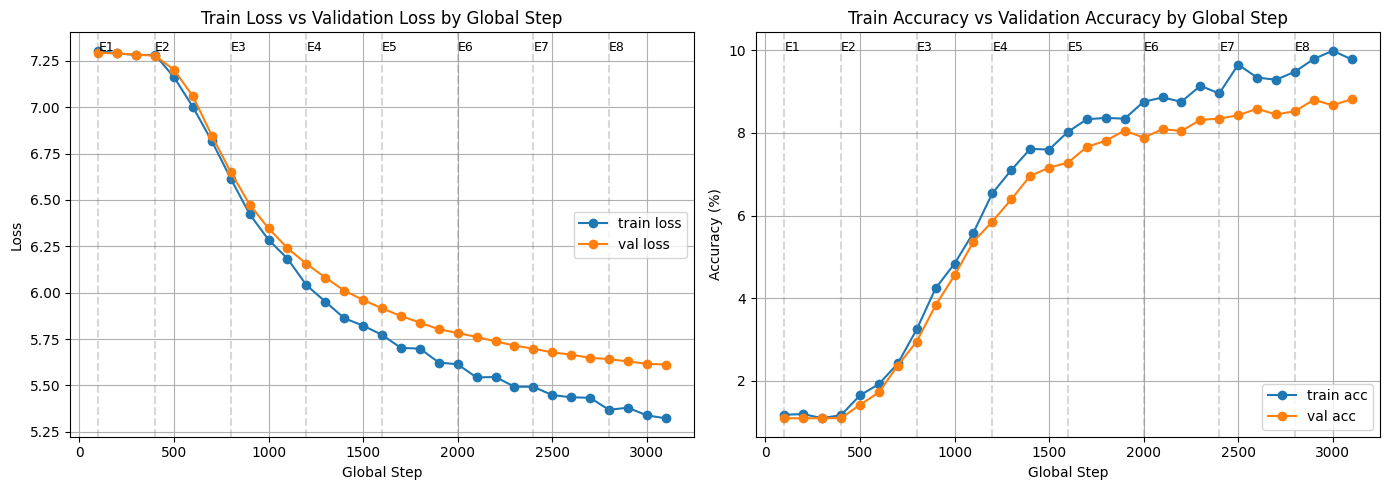

graph saved: /content/drive/MyDrive/W14-gpt-lab/outputs/experiment_001_lower_lr_epoch8/experiment_001_lower_lr_epoch8_loss_acc_graph.png
experiment index saved: /content/drive/MyDrive/W14-gpt-lab/outputs/experiment_index.csv


,experiment,run_name,vocab_size,context_length,batch_size,num_epochs,learning_rate,weight_decay,emb_dim,n_heads,n_layers,drop_rate,final_train_loss,final_val_loss,final_train_acc,final_val_acc,output_dir
0,experiment_001,experiment_001_lower_lr_epoch8,3000,128,16,8,0.0003,0.01,192,4,4,0.2,5.322127,5.612296,0.097803,0.088184,/content/drive/MyDrive/W14-gpt-lab/outputs/exp...


In [21]:
from pathlib import Path
import time
import json
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import pandas as pd

from dataset import create_dataloader
from model import GPTModel
from train import save_checkpoint, generate_and_print_sample

assert "tokenizer" in globals(), "먼저 tokenizer load 셀을 실행하세요."
assert len(tokenizer.id_to_token) == 3000, f"vocab size가 3000이어야 합니다. 현재: {len(tokenizer.id_to_token)}"
assert "corpus" in globals(), "먼저 corpus 로드 셀을 실행하세요."

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

# ===== 실험 이름 / 저장 폴더 =====
BASE_RUN_NAME = "lower_lr_epoch8"

drive_output_root = Path("/content/drive/MyDrive/W14-gpt-lab/outputs")
drive_output_root.mkdir(parents=True, exist_ok=True)

existing_exps = sorted(drive_output_root.glob("experiment_*"))
exp_numbers = []

for exp_dir_candidate in existing_exps:
    try:
        exp_numbers.append(int(exp_dir_candidate.name.split("_")[1]))
    except:
        pass

exp_num = max(exp_numbers, default=0) + 1
EXP_NAME = f"experiment_{exp_num:03d}"
RUN_NAME = f"{EXP_NAME}_{BASE_RUN_NAME}"

exp_dir = drive_output_root / RUN_NAME
exp_dir.mkdir(parents=True, exist_ok=True)

print("RUN_NAME:", RUN_NAME)
print("experiment output dir:", exp_dir)

# ===== 하이퍼파라미터 설정 =====
CORPUS_SIZE = 1_500_000
context_length = 128
batch_size = 16
num_epochs = 8
learning_rate = 3e-4
weight_decay = 0.01

eval_freq = 100
eval_batches = 10

train_text = corpus[:CORPUS_SIZE]
val_text = val_corpus[:100_000] if "val_corpus" in globals() and val_corpus else corpus[CORPUS_SIZE:CORPUS_SIZE + 100_000]
# ===== token id cache =====
# 같은 tokenizer + 같은 corpus 크기면 encode 결과가 같으므로 Drive에 저장해두고 재사용한다.
token_cache_dir = Path("/content/drive/MyDrive/W14-gpt-lab/cache")
token_cache_dir.mkdir(parents=True, exist_ok=True)

VAL_SIZE = 100_000
TOKEN_CACHE_NAME = f"vocab{len(tokenizer.id_to_token)}_train{CORPUS_SIZE}_val{VAL_SIZE}"

train_cache_path = token_cache_dir / f"{TOKEN_CACHE_NAME}_train_ids.pt"
val_cache_path = token_cache_dir / f"{TOKEN_CACHE_NAME}_val_ids.pt"

train_text = corpus[:CORPUS_SIZE]
val_text = val_corpus[:VAL_SIZE] if "val_corpus" in globals() and val_corpus else corpus[CORPUS_SIZE:CORPUS_SIZE + VAL_SIZE]

print("train chars:", len(train_text))
print("val chars:", len(val_text))

if train_cache_path.exists() and val_cache_path.exists():
    print("token cache found. loading token ids...")
    train_ids = torch.load(train_cache_path, map_location="cpu").tolist()
    val_ids = torch.load(val_cache_path, map_location="cpu").tolist()
    print("token cache loaded:", token_cache_dir)
else:
    print("token cache not found. encoding text...")
    token_start = time.perf_counter()

    train_ids = tokenizer.encode(train_text)
    val_ids = tokenizer.encode(val_text)

    torch.save(torch.tensor(train_ids, dtype=torch.long), train_cache_path)
    torch.save(torch.tensor(val_ids, dtype=torch.long), val_cache_path)

    token_elapsed = time.perf_counter() - token_start
    print("token cache saved:", token_cache_dir)
    print("tokenizing time sec:", round(token_elapsed, 2))
    print("tokenizing time min:", round(token_elapsed / 60, 2))

print("train tokens:", len(train_ids))
print("val tokens:", len(val_ids))

train_loader = create_dataloader(
    train_ids,
    context_length=context_length,
    batch_size=batch_size,
    shuffle=True,
)

val_loader = create_dataloader(
    val_ids,
    context_length=context_length,
    batch_size=batch_size,
    shuffle=False,
)

config = {
    "vocab_size": len(tokenizer.id_to_token),
    "context_length": context_length,
    "emb_dim": 192,
    "n_heads": 4,
    "n_layers": 4,
    "drop_rate": 0.2,
    "qkv_bias": False,
}

model = GPTModel(config).to(device)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=learning_rate,
    weight_decay=weight_decay,
)


def evaluate_loader(model, data_loader, device, num_batches=10):
    model.eval()

    total_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for batch_idx, (input_ids, target_ids) in enumerate(data_loader):
            if batch_idx >= num_batches:
                break

            input_ids = input_ids.to(device)
            target_ids = target_ids.to(device)

            logits = model(input_ids)

            loss = F.cross_entropy(
                logits.reshape(-1, logits.size(-1)),
                target_ids.reshape(-1),
            )

            pred_ids = torch.argmax(logits, dim=-1)

            total_loss += loss.item()
            correct += (pred_ids == target_ids).sum().item()
            total += target_ids.numel()

    model.train()

    avg_loss = total_loss / max(1, min(num_batches, len(data_loader)))
    accuracy = correct / total if total > 0 else 0.0

    return avg_loss, accuracy


history = []

global_step = 0
start = time.perf_counter()

for epoch in range(num_epochs):
    model.train()

    for input_ids, target_ids in train_loader:
        global_step += 1

        input_ids = input_ids.to(device)
        target_ids = target_ids.to(device)

        logits = model(input_ids)

        loss = F.cross_entropy(
            logits.reshape(-1, logits.size(-1)),
            target_ids.reshape(-1),
        )

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if global_step % eval_freq == 0:
            train_loss, train_acc = evaluate_loader(
                model,
                train_loader,
                device,
                num_batches=eval_batches,
            )

            val_loss, val_acc = evaluate_loader(
                model,
                val_loader,
                device,
                num_batches=eval_batches,
            )

            if len(history) == 0:
                loss_drop = 0.0
            else:
                prev_train_loss = history[-1]["train_loss"]
                loss_drop = (prev_train_loss - train_loss) / prev_train_loss * 100

            row = {
                "run_name": RUN_NAME,
                "epoch": epoch + 1,
                "global_step": global_step,
                "train_loss": train_loss,
                "val_loss": val_loss,
                "train_acc": train_acc,
                "val_acc": val_acc,
                "loss_drop_percent": loss_drop,
            }

            history.append(row)

            print(
                f"Epoch {epoch + 1}/{num_epochs} | "
                f"step {global_step} | "
                f"train loss {train_loss:.4f} | "
                f"val loss {val_loss:.4f} | "
                f"train acc {train_acc * 100:.2f}% | "
                f"val acc {val_acc * 100:.2f}% | "
                f"loss drop {loss_drop:.2f}%"
            )

            generate_and_print_sample(
                model=model,
                tokenizer=tokenizer,
                device=device,
                start_context="이 영화는",
                max_new_tokens=50,
                context_size=context_length,
                temperature=0.8,
                top_k=40,
            )

elapsed = time.perf_counter() - start

history_df = pd.DataFrame(history)

# ===== 저장 경로 =====
ckpt_path = exp_dir / f"{RUN_NAME}.pt"
history_path = exp_dir / f"{RUN_NAME}_history.csv"
summary_path = exp_dir / f"{RUN_NAME}_summary.txt"
graph_path = exp_dir / f"{RUN_NAME}_loss_acc_graph.png"
config_path = exp_dir / f"{RUN_NAME}_config.json"
index_path = drive_output_root / "experiment_index.csv"

save_checkpoint(
    model=model,
    optimizer=optimizer,
    epoch=num_epochs,
    global_step=global_step,
    path=str(ckpt_path),
)

history_df.to_csv(history_path, index=False)

final_train_loss = history_df["train_loss"].iloc[-1]
final_val_loss = history_df["val_loss"].iloc[-1]
final_train_acc = history_df["train_acc"].iloc[-1]
final_val_acc = history_df["val_acc"].iloc[-1]

save_config = {
    "vocab_size": len(tokenizer.id_to_token),
    "context_length": context_length,
    "emb_dim": config["emb_dim"],
    "n_heads": config["n_heads"],
    "n_layers": config["n_layers"],
    "drop_rate": config["drop_rate"],
    "qkv_bias": config["qkv_bias"],
    "learning_rate": learning_rate,
    "weight_decay": weight_decay,
}

config_path.write_text(
    json.dumps(save_config, ensure_ascii=False, indent=2),
    encoding="utf-8",
)

summary_text = f"""
RUN_NAME: {RUN_NAME}

[Hyperparameters]
CORPUS_SIZE: {CORPUS_SIZE}
vocab_size: {len(tokenizer.id_to_token)}
context_length: {context_length}
batch_size: {batch_size}
num_epochs: {num_epochs}
learning_rate: {learning_rate}
weight_decay: {weight_decay}
emb_dim: {config["emb_dim"]}
n_heads: {config["n_heads"]}
n_layers: {config["n_layers"]}
drop_rate: {config["drop_rate"]}
qkv_bias: {config["qkv_bias"]}

[Data]
train chars: {len(train_text)}
val chars: {len(val_text)}
train tokens: {len(train_ids)}
val tokens: {len(val_ids)}

[Final Result]
final train loss: {final_train_loss}
final val loss: {final_val_loss}
final train acc: {final_train_acc}
final val acc: {final_val_acc}

[Time]
training time sec: {round(elapsed, 2)}
training time min: {round(elapsed / 60, 2)}

[Saved Files]
checkpoint: {ckpt_path}
history csv: {history_path}
config json: {config_path}
graph png: {graph_path}
"""

summary_path.write_text(summary_text, encoding="utf-8")

print()
print("training time sec:", round(elapsed, 2))
print("training time min:", round(elapsed / 60, 2))
print("checkpoint saved:", ckpt_path)
print("history saved:", history_path)
print("config saved:", config_path)
print("summary saved:", summary_path)

print()
print("final train loss:", final_train_loss)
print("final val loss:", final_val_loss)
print("final train acc:", final_train_acc)
print("final val acc:", final_val_acc)

display(history_df)

# ===== 그래프 저장 =====
steps = history_df["global_step"]
train_losses = history_df["train_loss"]
val_losses = history_df["val_loss"]
train_accs = history_df["train_acc"] * 100
val_accs = history_df["val_acc"] * 100

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(steps, train_losses, marker="o", label="train loss")
plt.plot(steps, val_losses, marker="o", label="val loss")

for epoch_num in sorted(history_df["epoch"].unique()):
    first_step = history_df[history_df["epoch"] == epoch_num]["global_step"].iloc[0]
    plt.axvline(first_step, color="gray", linestyle="--", alpha=0.3)
    plt.text(first_step, max(max(train_losses), max(val_losses)), f"E{epoch_num}", fontsize=9)

plt.xlabel("Global Step")
plt.ylabel("Loss")
plt.title("Train Loss vs Validation Loss by Global Step")
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(steps, train_accs, marker="o", label="train acc")
plt.plot(steps, val_accs, marker="o", label="val acc")

for epoch_num in sorted(history_df["epoch"].unique()):
    first_step = history_df[history_df["epoch"] == epoch_num]["global_step"].iloc[0]
    plt.axvline(first_step, color="gray", linestyle="--", alpha=0.3)
    plt.text(first_step, max(max(train_accs), max(val_accs)), f"E{epoch_num}", fontsize=9)

plt.xlabel("Global Step")
plt.ylabel("Accuracy (%)")
plt.title("Train Accuracy vs Validation Accuracy by Global Step")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig(graph_path, dpi=200, bbox_inches="tight")
plt.show()

print("graph saved:", graph_path)

# ===== 전체 실험 인덱스 저장 =====
experiment_row = {
    "experiment": EXP_NAME,
    "run_name": RUN_NAME,
    "vocab_size": len(tokenizer.id_to_token),
    "context_length": context_length,
    "batch_size": batch_size,
    "num_epochs": num_epochs,
    "learning_rate": learning_rate,
    "weight_decay": weight_decay,
    "emb_dim": config["emb_dim"],
    "n_heads": config["n_heads"],
    "n_layers": config["n_layers"],
    "drop_rate": config["drop_rate"],
    "final_train_loss": final_train_loss,
    "final_val_loss": final_val_loss,
    "final_train_acc": final_train_acc,
    "final_val_acc": final_val_acc,
    "output_dir": str(exp_dir),
}

if index_path.exists():
    index_df = pd.read_csv(index_path)
    index_df = pd.concat([index_df, pd.DataFrame([experiment_row])], ignore_index=True)
else:
    index_df = pd.DataFrame([experiment_row])

index_df.to_csv(index_path, index=False)

print("experiment index saved:", index_path)
display(index_df.tail())

In [ ]:
import os
import sys
from pathlib import Path

repo_dir = Path("/content/W14-gpt-lab")

os.chdir(repo_dir)

src_dir = repo_dir / "src"
if str(src_dir) not in sys.path:
    sys.path.insert(0, str(src_dir))

print("cwd:", Path.cwd())
print("src exists:", src_dir.exists())
print("train.py exists:", (src_dir / "train.py").exists())

cwd: /content/W14-gpt-lab
src exists: True
train.py exists: True


학습 끝나고 저장하는 셀

In [ ]:
import torch
from train import generate

model.eval()

start_text = "이 영화는"
start_ids = tokenizer.encode(start_text, add_bos_eos=False)

idx = torch.tensor(start_ids, dtype=torch.long, device=device).unsqueeze(0)

out = generate(
    model=model,
    idx=idx,
    max_new_tokens=50,
    context_size=config["context_length"],
    temperature=0.8,
    top_k=20,
    eos_id=tokenizer.get_eos_id(),
)

generated_text = tokenizer.decode(out[0].tolist())
print(generated_text)

이 영화는 지겹다 이정도가 보이는 장면은 그러대의 극하게 다행에 영화... 지루아. 그냥 영화... 재밌다는거운 일이렇게 저럭저럭고 이럴데..
영화는영화였습니다.
로 안


# FINETUNE

## 8. Step 6 - 감성 분류 미세 조정

구현 파일: `src/finetune.py`

NSMC JSONL/TSV를 읽어 분류 Dataset을 만들고, GPT backbone 위에 classification head를 붙입니다.

In [ ]:
run_pytest("tests/test_finetune.py")

실행 명령: /usr/bin/python3 -m pytest tests/test_finetune.py -v
============================= test session starts ==============================
platform linux -- Python 3.12.13, pytest-8.4.2, pluggy-1.6.0 -- /usr/bin/python3
cachedir: .pytest_cache
rootdir: /content/W14-gpt-lab
plugins: typeguard-4.5.2, langsmith-0.8.5, anyio-4.13.0
collecting ... collected 4 items

tests/test_finetune.py::TestMakeSentimentDataset::test_make_sentiment_dataset_splits_rows PASSED [ 25%]
tests/test_finetune.py::TestReviewSentimentDataset::test_review_sentiment_dataset_getitem PASSED [ 50%]
tests/test_finetune.py::TestGPTForSequenceClassification::test_sequence_classification_shape PASSED [ 75%]
tests/test_finetune.py::TestSentimentTrainEval::test_train_eval_functions_exist PASSED [100%]

============================== 4 passed in 2.50s ===============================


선택한 테스트를 통과했습니다.


0

감성분류 미세조정

In [ ]:
import json
import torch
from pathlib import Path
from torch.utils.data import DataLoader

from model import GPTModel
from train import load_checkpoint
from finetune import ReviewSentimentDataset, GPTForSequenceClassification, train_epoch_sentiment, evaluate_sentiment

def read_jsonl(path):
    data = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            data.append(json.loads(line))
    return data

train_data = read_jsonl("data/nsmc_sentiment_train.jsonl")
val_data = read_jsonl("data/nsmc_sentiment_val.jsonl")
test_data = read_jsonl("data/nsmc_sentiment_test.jsonl")

# 너무 오래 걸리면 처음에는 일부만 사용
train_data = train_data[:20_000]
val_data = val_data[:5_000]
test_data = test_data[:5_000]

max_length = 128
batch_size = 16

train_ds = ReviewSentimentDataset(train_data, tokenizer, max_length=max_length)
val_ds = ReviewSentimentDataset(val_data, tokenizer, max_length=max_length)
test_ds = ReviewSentimentDataset(test_data, tokenizer, max_length=max_length)

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

backbone = GPTModel(config).to(device)

load_checkpoint(
    model=backbone,
    optimizer=None,
    path=str(ckpt_path),
    device=device,
)

clf_model = GPTForSequenceClassification(
    gpt_model=backbone,
    num_labels=2,
    drop_rate=0.1,
).to(device)

optimizer = torch.optim.AdamW(clf_model.parameters(), lr=3e-4, weight_decay=0.01)

num_epochs = 3
best_val_acc = 0.0
best_path = drive_ckpt_dir / "gpt_sentiment_best.pt"

for epoch in range(num_epochs):
    train_loss, train_acc = train_epoch_sentiment(
        model=clf_model,
        train_loader=train_loader,
        optimizer=optimizer,
        device=device,
    )

    val_loss, val_acc = evaluate_sentiment(
        model=clf_model,
        data_loader=val_loader,
        device=device,
    )

    print(
        f"epoch {epoch + 1} | "
        f"train loss {train_loss:.4f}, train acc {train_acc:.4f} | "
        f"val loss {val_loss:.4f}, val acc {val_acc:.4f}"
    )

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(clf_model.state_dict(), best_path)
        print("best checkpoint saved:", best_path)

test_loss, test_acc = evaluate_sentiment(
    model=clf_model,
    data_loader=test_loader,
    device=device,
)

print("test loss:", test_loss)
print("test acc:", test_acc)

## 9. 전체 테스트와 제출 전 확인

각 단계 테스트가 모두 통과하면 마지막에 전체 테스트를 실행합니다.

In [ ]:
run_pytest("tests/")

실행 명령: /usr/bin/python3 -m pytest tests/ -v
============================= test session starts ==============================
platform linux -- Python 3.12.13, pytest-8.4.2, pluggy-1.6.0 -- /usr/bin/python3
cachedir: .pytest_cache
rootdir: /content/W14-gpt-lab
plugins: typeguard-4.5.2, langsmith-0.8.5, anyio-4.13.0
collecting ... collected 28 items

tests/test_attention.py::TestMultiHeadAttention::test_mha_output_shape PASSED [  3%]
tests/test_attention.py::TestMultiHeadAttention::test_mha_causal_mask_future_zero PASSED [  7%]
tests/test_bpe.py::TestSpecialTokens::test_special_ids_fixed PASSED      [ 10%]
tests/test_bpe.py::TestBPETokenizer::test_init_special_tokens PASSED     [ 14%]
tests/test_bpe.py::TestBPETokenizer::test_save_load_restores_vocab PASSED [ 17%]
tests/test_bpe.py::TestBPETokenizer::test_encode_decode_restores_original_text PASSED [ 21%]
tests/test_bpe.py::TestBPETokenizer::test_get_special_ids PASSED         [ 25%]
tests/test_bpe.py::TestBPETrain::test_train_increases_

0